In [1]:
# Imports
import os
import sys
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Sklearn
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Projekt-Pfad anpassen 
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from ML_Helpfunctions import Feature_Engeneering as fe
from ML_Helpfunctions import Load_Prepare_Data as LoadPrepareData
from ML_Helpfunctions import Pipeline_Utils as PipelineUtils 
from ML_Helpfunctions import RF_Utils as RFUtils
from ML_Algorithms import RF_Run_Pipeline as RFRunPipeline
 

BASE_DIR = Path().resolve().parent  # geht ein Verzeichnis nach oben von ML_Notebooks
INPUT_DIR = BASE_DIR / "Input"
OUTPUT_DIR = BASE_DIR / "Output"


CONFIG_RF_ALL = {
    # ---- Pfade bleiben erhalten (lokales Setup) ----
    "paths": {
        "base": BASE_DIR,
        "input": INPUT_DIR,
        "output": OUTPUT_DIR,

        # Input Unterordner entsprechend deinem Beispiel
        "input_data": INPUT_DIR / "Input_Data",
        "input_models": INPUT_DIR / "Input_Models",
        "input_scaler": INPUT_DIR / "Input_Scaler",

        # Fixer Output-Pfad für Fehler-Metriken
        "output_error_metrics": OUTPUT_DIR / "Error_Metrics",

        # Falls du weitere Pfade brauchst, z.B. für Modelle / Loss Plots, kannst du sie hier ergänzen:
        "Models": OUTPUT_DIR / "Models",
        "Loss_Plots": OUTPUT_DIR / "Loss_Plots",
        "Model_Structures": OUTPUT_DIR / "Model_Structures",
    },

    # ---- Modellname und aktueller Timestamp ----
    "model_name": "random_forest_server_train_small_revpi",
    "time_stamp": datetime.now().strftime("%Y-%m-%d_%H%M%S"),

    # ---- Datensatz ----
    "dataset": "dataset3_m_v1.csv",

    # ---- Modellparameter (für RF) ----
    "n_estimators": 100,
    "max_depth": 25,
    "min_samples_split": 5,
    "min_samples_leaf": 3,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": 1,

    # ---- Modell-Dateinamen ----
    "model_params": {
        "saved_model_name": "random_forest_model.pkl",
        "scaler_name": "scaler.pkl"
    },

    # ---- Zeitreihenparameter ----
    "lags": 10,
    "horizon": 2,
    "train_fraction": 0.3,
    "rolling_window_size": 5,

    # ---- Feature-Konfiguration ----
    "base_features": ['Volume_Flow', 'Pressure_Hall'],
    # "time_features": [
    #     'second', "minute", "minute_sin", "minute_cos", "hour", "hour_sin", "hour_cos",
    #     "day_of_month", "day_of_week", "is_weekend", "month", "month_sin", "month_cos"
    # ],
    "time_features": [],

    # ---- Feature Engineering ----
    "include_roll_mean": True,
    "include_roll_std": True,
    "scale_other_features": False,
    "scale_target": False,
}



✅ Experiment-Setup abgeschlossen. Run ID: 2025-07-03_115349_7058
📁 Ergebnisordner: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\2025-07-03_115349_7058

Schritt 1: Lade Trainings- und Testdaten...
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\dataset3_m_v1.csv
Geladen: 241920 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\dataset3_m_v1.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\dataset3_m_v1.csv
Geladen: 241920 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\dataset3_m_v1.csv' mit Zeitfeatures

Schritt 2: Feature Engineering...

[DEBUG] Spaltennamen im Trainings-DataFrame NACH Feature Engineering:
['Volume_Flow', 'Pressure_Hall', 'millisecond', 'second', 'minute'

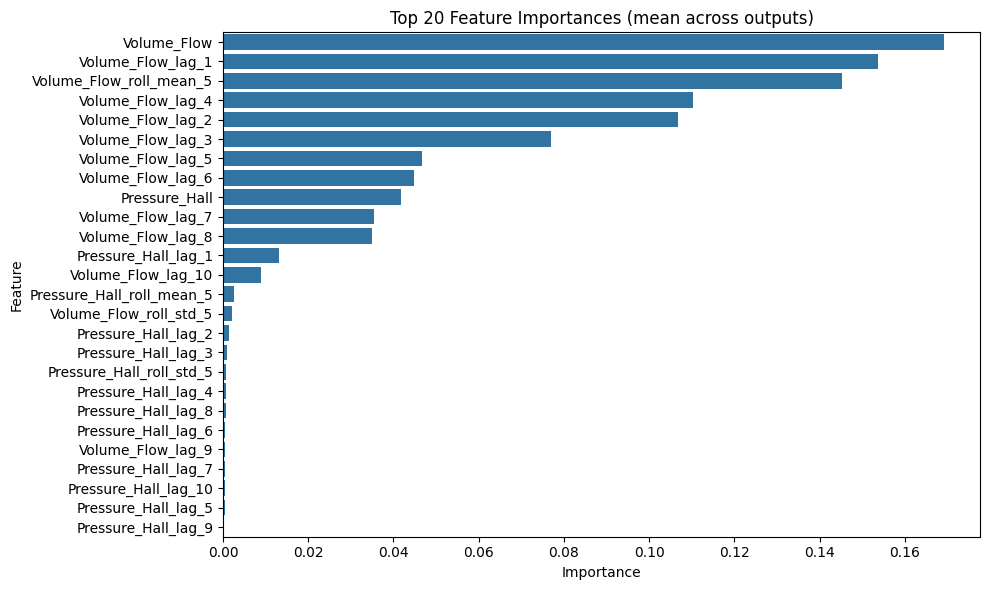

In [3]:
# ----- Funktionen (aus deinem Script übernommen) -----

# model, metrics, results = RFRunPipeline.run_full_pipeline_rf(CONFIG_RF_ALL)

model, full_feature_list = RFRunPipeline.run_full_pipeline_rf_without_save(CONFIG_RF_ALL)

all_importances = []
for i, estimator in enumerate(model.estimators_):
    importances = estimator.feature_importances_
    all_importances.append(importances)

# all_importances ist eine Liste von Arrays (je Output ein Array)

# Mittelwert über alle Outputs (je Feature)
mean_importances = np.mean(all_importances, axis=0)

feature_importance_df = pd.DataFrame({
    'Feature': full_feature_list,
    'Importance': mean_importances
}).sort_values(by='Importance', ascending=False)

print("\nTop Feature Importances:")
print(feature_importance_df.head(30))

# Optional: Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance_df.head(30), x='Importance', y='Feature')
plt.title("Top 20 Feature Importances (mean across outputs)")
plt.tight_layout()
plt.show()


🔎 Verarbeitung: Dataset=filtered_wanda_dataset.csv, Lags=2
✅ Experiment-Setup abgeschlossen. Run ID: 2025-07-01_103525_5467
📁 Ergebnisordner: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\2025-07-01_103525_5467

Schritt 1: Lade Trainings- und Testdaten...
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures
✔️ Datendatei gefunden: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv
Geladen: 235421 Zeilen aus 'C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Input\Input_Data\filtered_wanda_dataset.csv' mit Zeitfeatures

Schritt 2: Feature Engineering...
Trainingsdaten: (70621, 19), Testdaten: (1

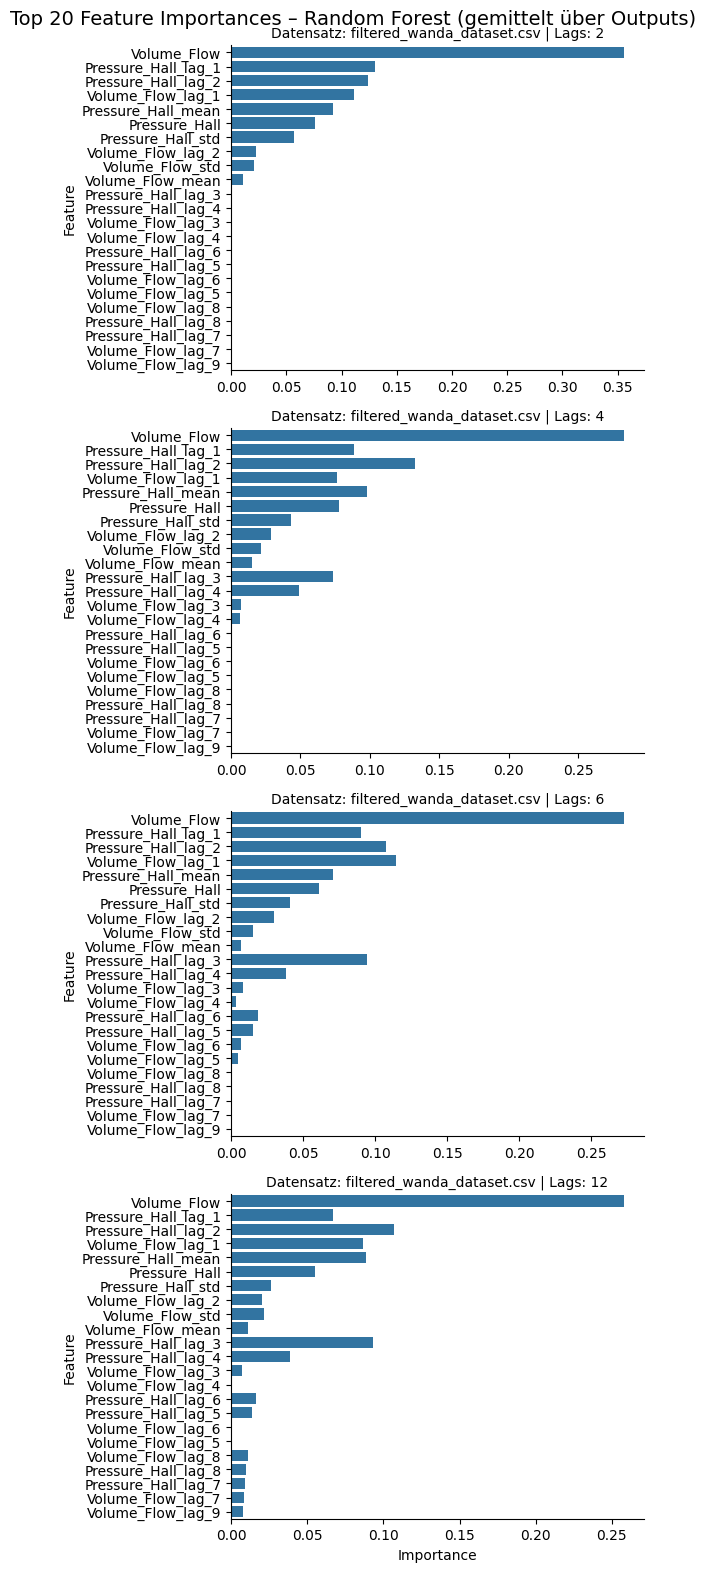

In [6]:
from copy import deepcopy

BASE_DIR = Path().resolve().parent  # geht ein Verzeichnis nach oben von ML_Notebooks
INPUT_DIR = BASE_DIR / "Input"
OUTPUT_DIR = BASE_DIR / "Output"
CONFIG_RF_ALL = {
    # ---- Pfade bleiben erhalten (lokales Setup) ----
    "paths": {
        "base": BASE_DIR,
        "input": INPUT_DIR,
        "output": OUTPUT_DIR,

        # Input Unterordner entsprechend deinem Beispiel
        "input_data": INPUT_DIR / "Input_Data",
        "input_models": INPUT_DIR / "Input_Models",
        "input_scaler": INPUT_DIR / "Input_Scaler",

        # Fixer Output-Pfad für Fehler-Metriken
        "output_error_metrics": OUTPUT_DIR / "Error_Metrics",

        # Falls du weitere Pfade brauchst, z.B. für Modelle / Loss Plots, kannst du sie hier ergänzen:
        "Models": OUTPUT_DIR / "Models",
        "Loss_Plots": OUTPUT_DIR / "Loss_Plots",
        "Model_Structures": OUTPUT_DIR / "Model_Structures",
    },

    # ---- Modellname und aktueller Timestamp ----
    "model_name": "random_forest_server_train_small_revpi",
    "time_stamp": datetime.now().strftime("%Y-%m-%d_%H%M%S"),

    # ---- Datensatz ----
    "dataset": "dataset3_m_v1.csv",

    # ---- Modellparameter (für RF) ----
    "n_estimators": 100,
    "max_depth": 25,
    "min_samples_split": 5,
    "min_samples_leaf": 3,
    "max_features": "sqrt",
    "random_state": 42,
    "n_jobs": 1,

    # ---- Modell-Dateinamen ----
    "model_params": {
        "saved_model_name": "random_forest_model.pkl",
        "scaler_name": "scaler.pkl"
    },

    # ---- Zeitreihenparameter ----
    "lags": 10,
    "horizon": 2,
    "train_fraction": 0.3,
    "rolling_window_size": 5,

    # ---- Feature-Konfiguration ----
    "base_features": ['Volume_Flow', 'Pressure_Hall'],
    # "time_features": [
    #     'second', "minute", "minute_sin", "minute_cos", "hour", "hour_sin", "hour_cos",
    #     "day_of_month", "day_of_week", "is_weekend", "month", "month_sin", "month_cos"
    # ],
    "time_features": [],

    # ---- Feature Engineering ----
    "include_roll_mean": True,
    "include_roll_std": True,
    "scale_other_features": False,
    "scale_target": False,
}

BASE_CONFIG = deepcopy(CONFIG_RF_ALL)
DATASETS = [
 "filtered_wanda_dataset.csv"
]

LAGS = [2, 4, 6, 12]

# Ergebnisse zwischenspeichern
importance_results = []

for dataset in DATASETS:
    for lag in LAGS:
        print(f"🔎 Verarbeitung: Dataset={dataset}, Lags={lag}")

        # Konfiguration anpassen
        config = deepcopy(BASE_CONFIG)
        config["dataset"] = dataset
        config["lags"] = lag

        # Modellpipeline aufrufen
        model, feature_list = RFRunPipeline.run_full_pipeline_rf_without_save(config)

        # Feature Importances pro Estimator (Output) sammeln
        all_importances = []
        for estimator in model.estimators_:
            all_importances.append(estimator.feature_importances_)

        # Mittelwert über Outputs
        mean_importances = np.mean(all_importances, axis=0)

        # Speichern
        df = pd.DataFrame({
            "Feature": feature_list,
            "Importance": mean_importances,
            "Dataset": dataset,
            "Lags": f"{lag}"
        }).sort_values(by="Importance", ascending=False).head(20)

        importance_results.append(df)

# Gesamt-DataFrame
importance_all_df = pd.concat(importance_results, ignore_index=True)

# 💡 Optional: Feature-Namen etwas kürzen für die Achsen
importance_all_df["Feature"] = importance_all_df["Feature"].apply(lambda x: x.replace("_roll_mean_5", "_mean").replace("_roll_std_5", "_std"))

# ✅ Visualisierung
g = sns.catplot(
    data=importance_all_df,
    x="Importance", y="Feature",
    col="Dataset", row="Lags",
    kind="bar",
    height=4, aspect=1.5,
    sharex=False
)

g.set_titles("Datensatz: {col_name} | Lags: {row_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Top 20 Feature Importances – Random Forest (gemittelt über Outputs)", fontsize=14)

plt.tight_layout()
plt.show()